In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.config import FIGURES, PREPARE, SEUIL_BAYES
from src.cout import depondere
from src.evaluation import evalue
from src.graines import set_seed
from src.pertes import (entropie_croisee_ponderee, focale_ponderee,
                        perte_focale)
import src.modeles as M

set_seed()

X_app = pd.read_csv(PREPARE / "X_app_final.csv", index_col=0)
y_app = pd.read_csv(PREPARE / "y_app.csv", index_col=0).squeeze()

T_CRITIQUE = stats.t.ppf(0.975, df=4)
ARCHITECTURE = (64, 32)   # retenue au banc d'essai

print(f"Architecture retenue au banc d'essai : {ARCHITECTURE}")
print(f"Seuil de Student, quatre degrés de liberté : {T_CRITIQUE:.3f}")

2026-08-26 17:20:11.772220: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 17:20:12.061230: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Architecture retenue au banc d'essai : (64, 32)
Seuil de Student, quatre degrés de liberté : 2.776


In [2]:
variantes = {
    "A, référence": dict(perte="standard", ponderation=True),
    "B, perte pondérée": dict(perte=entropie_croisee_ponderee(),
                              ponderation=False),
    "C, perte focale": dict(perte=perte_focale(alpha=0.75, gamma=2.0),
                            ponderation=False),
    "D, focale pondérée": dict(perte=focale_ponderee(gamma=2.0),
                               ponderation=False),
}

resultats = {}
for nom, config in variantes.items():
    t0 = time.time()
    resultats[nom] = evalue(
        lambda c=config: M.PerceptronKeras(couches=ARCHITECTURE, epochs=20, **c),
        X_app, y_app, nom, n_jobs=1)
    r = resultats[nom]
    print(f"{nom:<22} coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   détection {r['rappel'].mean():.1%}"
          f"   pannes ratées {r['FN'].mean():.1f}"
          f"   ({(time.time() - t0) / 60:.1f} min)")

A, référence           coût    8,550 ±  1,838   détection 93.9%   pannes ratées 9.8   (2.5 min)
B, perte pondérée      coût    8,368 ±  1,008   détection 94.6%   pannes ratées 8.6   (2.5 min)
C, perte focale        coût    9,210 ±  1,781   détection 94.1%   pannes ratées 9.4   (2.5 min)
D, focale pondérée     coût    8,430 ±    687   détection 94.5%   pannes ratées 8.8   (2.5 min)


In [3]:
detail = pd.DataFrame({
    nom: {
        "cout": r["cout"].mean(),
        "dispersion": r["cout"].std(),
        "detection": r["rappel"].mean(),
        "fiabilite": r["precision"].mean(),
        "pannes_ratees": r["FN"].mean(),
        "fausses_alertes": r["FP"].mean(),
        "auc_pr": r["auc_pr"].mean(),
        "seuil": r["seuil"].mean(),
    }
    for nom, r in resultats.items()
}).T.round(4)

print(detail.to_string())
print("\nRappel : une panne ratée coûte 500 unités, une fausse alerte 10.")

                      cout  dispersion  detection  fiabilite  pannes_ratees  fausses_alertes  auc_pr   seuil
A, référence        8550.0   1837.8656     0.9388     0.2942            9.8            365.0  0.7573  0.2814
B, perte pondérée   8368.0   1007.6061     0.9462     0.2766            8.6            406.8  0.7565  0.2312
C, perte focale     9210.0   1780.8425     0.9412     0.2534            9.4            451.0  0.7966  0.1532
D, focale pondérée  8430.0    686.5493     0.9450     0.2827            8.8            403.0  0.7538  0.3190

Rappel : une panne ratée coûte 500 unités, une fausse alerte 10.


In [4]:
def compare(reference, alternative, nom_ref, nom_alt, mesure="cout"):
    """Paired comparison on identical folds."""
    d = alternative[mesure].values - reference[mesure].values
    moyenne = d.mean()
    erreur = d.std(ddof=1) / np.sqrt(len(d))
    significatif = abs(moyenne) > T_CRITIQUE * erreur

    print(f"{nom_alt} moins {nom_ref}, sur {mesure}")
    print(f"  par partie : {np.round(d, 3)}")
    print(f"  écart moyen : {moyenne:+,.2f} ± {erreur:,.2f}")
    print(f"  écart significatif : {'oui' if significatif else 'non'}\n")

    return {"ecart": moyenne, "erreur": erreur, "significatif": significatif}


print("HYPOTHÈSE H1\n")
h1 = compare(resultats["A, référence"], resultats["B, perte pondérée"],
             "A", "B")


HYPOTHÈSE H1

B moins A, sur cout
  par partie : [ 2460 -1740  -690   120 -1060]
  écart moyen : -182.00 ± 725.52
  écart significatif : non



In [5]:
print("Décomposition par type d'erreur\n")
for mesure in ["FN", "FP", "rappel", "auc_pr"]:
    compare(resultats["A, référence"], resultats["B, perte pondérée"],
            "A", "B", mesure=mesure)


Décomposition par type d'erreur

B moins A, sur FN
  par partie : [ 1 -4 -2  1 -2]
  écart moyen : -1.20 ± 0.97
  écart significatif : non

B moins A, sur FP
  par partie : [196  26  31 -38  -6]
  écart moyen : +41.80 ± 40.49
  écart significatif : non

B moins A, sur rappel
  par partie : [-0.006  0.025  0.012 -0.006  0.012]
  écart moyen : +0.01 ± 0.01
  écart significatif : non

B moins A, sur auc_pr
  par partie : [-0.007 -0.004 -0.001  0.009 -0.001]
  écart moyen : -0.00 ± 0.00
  écart significatif : non



In [6]:
print("Situer le résultat : les autres variantes contre la référence\n")
autres = {}
for nom in ["C, perte focale", "D, focale pondérée"]:
    autres[nom] = compare(resultats["A, référence"], resultats[nom], "A", nom)

Situer le résultat : les autres variantes contre la référence

C, perte focale moins A, sur cout
  par partie : [1370 -740  260 1760  650]
  écart moyen : +660.00 ± 437.85
  écart significatif : non

D, focale pondérée moins A, sur cout
  par partie : [ 2370 -1340  -320 -1570   260]
  écart moyen : -120.00 ± 706.24
  écart significatif : non



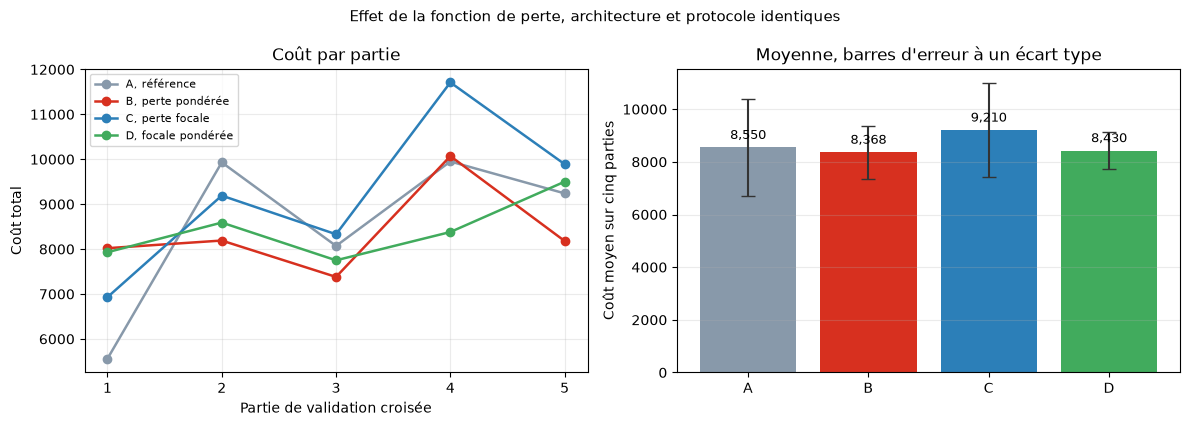

In [7]:
# Figure 1 : les quatre variantes
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

noms = list(resultats)
parties = np.arange(1, 6)
couleurs = ["#8899aa", "#d7301f", "#2c7fb8", "#41ab5d"]

for nom, couleur in zip(noms, couleurs):
    axes[0].plot(parties, resultats[nom]["cout"], "o-", color=couleur,
                 label=nom, lw=1.8)
axes[0].set_xlabel("Partie de validation croisée")
axes[0].set_ylabel("Coût total")
axes[0].set_title("Coût par partie")
axes[0].set_xticks(parties)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

moyennes = [resultats[n]["cout"].mean() for n in noms]
erreurs = [resultats[n]["cout"].std() for n in noms]
axes[1].bar(range(len(noms)), moyennes, yerr=erreurs, color=couleurs,
            error_kw={"ecolor": "#333333", "capsize": 5})
for i, m in enumerate(moyennes):
    axes[1].annotate(f"{m:,.0f}", (i, m), ha="center", xytext=(0, 6),
                     textcoords="offset points", fontsize=9)
axes[1].set_xticks(range(len(noms)))
axes[1].set_xticklabels([n.split(",")[0] for n in noms])
axes[1].set_ylabel("Coût moyen sur cinq parties")
axes[1].set_title("Moyenne, barres d'erreur à un écart type")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Effet de la fonction de perte, architecture et protocole "
             "identiques", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "f12_fonctions_perte.png", dpi=150)
plt.show()

In [8]:
calibration = pd.DataFrame({
    nom: {
        "seuil_brut": r["seuil"].mean(),
        "dispersion_seuil": r["seuil"].std(),
        "seuil_depondere": r["seuil_depondere"].mean(),
        "rapport_au_repere": (SEUIL_BAYES / r["seuil_depondere"].mean()
                              if r["seuil_depondere"].mean() > 1e-9 else np.nan),
    }
    for nom, r in resultats.items()
}).T.round(5)

print(calibration.to_string())
print(f"\nRepère théorique : {SEUIL_BAYES:.5f}")
print("\nLa dépondération n'a de sens que pour la variante A, dont la")
print("pondération multiplie effectivement la cote. Pour les variantes B, C")
print("et D, qui n'appliquent aucune pondération de classe, le seuil brut est")
print("directement comparable au repère théorique.")

                    seuil_brut  dispersion_seuil  seuil_depondere  rapport_au_repere
A, référence           0.28143           0.03673          0.00783            2.50474
B, perte pondérée      0.23120           0.03831          0.00603            3.25304
C, perte focale        0.15317           0.01555          0.00361            5.43051
D, focale pondérée     0.31895           0.04063          0.00936            2.09493

Repère théorique : 0.01961

La dépondération n'a de sens que pour la variante A, dont la
pondération multiplie effectivement la cote. Pour les variantes B, C
et D, qui n'appliquent aucune pondération de classe, le seuil brut est
directement comparable au repère théorique.


In [9]:
# Le seuil brut, directement comparable au repère pour B, C et D
print(f"{'variante':<22} {'seuil brut':>12} {'rapport au repère':>18}")
print("-" * 54)
for nom in ["B, perte pondérée", "C, perte focale", "D, focale pondérée"]:
    s = resultats[nom]["seuil"].mean()
    print(f"{nom:<22} {s:>12.5f} {s / SEUIL_BAYES:>18.1f}")

print(f"\nRepère théorique : {SEUIL_BAYES:.5f}")
print("\nUn rapport très supérieur à 1 indique que le modèle sur-estime le")
print("risque, ce qui est le comportement attendu d'une perte pondérée.")

variante                 seuil brut  rapport au repère
------------------------------------------------------
B, perte pondérée           0.23120               11.8
C, perte focale             0.15317                7.8
D, focale pondérée          0.31895               16.3

Repère théorique : 0.01961

Un rapport très supérieur à 1 indique que le modèle sur-estime le
risque, ce qui est le comportement attendu d'une perte pondérée.


In [10]:
meilleure = min(resultats, key=lambda n: resultats[n]["cout"].mean())
reference = "A, référence"

print(f"Variante de plus faible coût : {meilleure}\n")

if meilleure != reference:
    verdict = compare(resultats[reference], resultats[meilleure],
                      "A", meilleure)
    retenue = meilleure if verdict["significatif"] else reference
    motif = ("écart significatif au sens de la comparaison appariée"
             if verdict["significatif"]
             else "écart non significatif, la référence est conservée par "
                  "principe de simplicité")
else:
    retenue = reference
    motif = "la référence est déjà la meilleure"

print(f"Variante retenue : {retenue}")
print(f"Motif : {motif}")

Variante de plus faible coût : B, perte pondérée

B, perte pondérée moins A, sur cout
  par partie : [ 2460 -1740  -690   120 -1060]
  écart moyen : -182.00 ± 725.52
  écart significatif : non

Variante retenue : A, référence
Motif : écart non significatif, la référence est conservée par principe de simplicité


In [11]:
# Position du perceptron développé dans le banc d'essai
banc = pd.read_csv("../reports/benchmark.csv", index_col=0)
banc = banc.drop(index="témoin constant", errors="ignore")

classement = banc[["cout", "dispersion"]].copy()
classement.loc["Perceptron développé"] = [
    resultats[retenue]["cout"].mean(),
    resultats[retenue]["cout"].std(),
]
classement = classement.sort_values("cout").round(0)

print("Classement mis à jour\n")
print(classement.to_string())

ancien = banc.loc["Perceptron (64, 32)", "cout"]
nouveau = resultats[retenue]["cout"].mean()
print(f"\nPerceptron au banc d'essai : {ancien:,.0f}")
print(f"Perceptron développé       : {nouveau:,.0f}")
print(f"Écart                      : {nouveau - ancien:+,.0f}")


Classement mis à jour

                                 cout  dispersion
Gradient boosting 8/0.1        6576.0      1030.0
Forêt aléatoire 300/None/1     6714.0       530.0
Perceptron (64, 32)            8550.0      1838.0
Perceptron développé           8550.0      1838.0
SVM linéaire C=0.001           9326.0      1473.0
Régression logistique C=0.001  9598.0      1218.0

Perceptron au banc d'essai : 8,550
Perceptron développé       : 8,550
Écart                      : +0


In [12]:
# Enregistrement, pour la séance d'arbitrage
synthese = pd.DataFrame({
    nom: {
        "cout": r["cout"].mean(),
        "dispersion": r["cout"].std(),
        "detection": r["rappel"].mean(),
        "pannes_ratees": r["FN"].mean(),
        "fausses_alertes": r["FP"].mean(),
        "auc_pr": r["auc_pr"].mean(),
        "seuil": r["seuil"].mean(),
    }
    for nom, r in resultats.items()
}).T.sort_values("cout").round(4)

synthese.to_csv("../reports/fonctions_perte.csv")
print(synthese.to_string())

import json
with open("../reports/variante_perceptron_retenue.json", "w",
          encoding="utf-8") as fichier:
    json.dump({"variante": retenue, "motif": motif,
               "cout": float(resultats[retenue]["cout"].mean())},
              fichier, indent=2, ensure_ascii=False)
print(f"\nVariante retenue enregistrée : {retenue}")

                      cout  dispersion  detection  pannes_ratees  fausses_alertes  auc_pr   seuil
B, perte pondérée   8368.0   1007.6061     0.9462            8.6            406.8  0.7565  0.2312
D, focale pondérée  8430.0    686.5493     0.9450            8.8            403.0  0.7538  0.3190
A, référence        8550.0   1837.8656     0.9388            9.8            365.0  0.7573  0.2814
C, perte focale     9210.0   1780.8425     0.9412            9.4            451.0  0.7966  0.1532

Variante retenue enregistrée : A, référence
